## Challenge

##### Hello campers! Here's a challenge for the PythonML Camp. In the data folder, you can find the file students_pass_fail.csv. Your task is to build a machine learning model that predicts whether a student will pass or fail based on their grade and absences in the school year.
    
#### Description of the csv file: 
    grade,absences,label
    95,1,Pass
    "grade" ranges from 0-100 and represents the numerical GPA of the student.
    "absences" ranges from 0-20 and represents the number of days the student was absent in the schoo year.
    "label" represents pass ("Pass") or fail ("Fail") of the student.
    
#### You may use the following machine learning models to build your model:
    - Logistic Regression
    - KNN
    - Decision Tree
    - Random Forest
    - SVM
        
#### Have fun!

Hint: If using KNN, you may run into an error with this line of code: *point_color = cmap(predicted_class)* because your prediction returns "pass" or "fail", which is not a numerical value that the cmap function can use. Use this instead: *point_color = cmap(pd.factorize(predicted_class)[0])*

    

In [497]:
import pandas as pd


In [498]:
df=pd.read_csv("data/students_pass_fail.csv")
X=df[['grade','absences']]
y=pd.factorize(df['label'])[0]

df.head()

,grade,absences,label
0,95,1,Pass
1,92,0,Pass
2,90,2,Pass
3,88,1,Pass
4,86,3,Pass


In [499]:
from sklearn.model_selection import train_test_split

X_test, X_train, y_test, y_train = train_test_split(X,y, test_size=0.2, random_state=42)

In [500]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

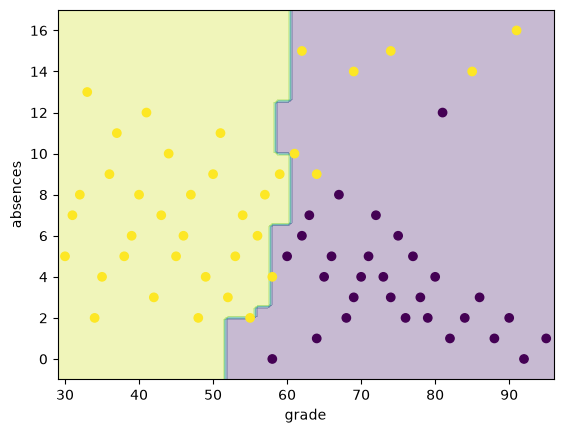

In [501]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
disp = DecisionBoundaryDisplay.from_estimator(
    model, X, response_method="predict", alpha=.3
)
plt.scatter(X['grade'],X['absences'], cmap='viridis',c=y)




In [502]:
y_pred=model.predict(X_test)
y_pred_train=model.predict(X_train)


In [503]:
from sklearn.metrics import accuracy_score, classification_report

print(accuracy_score(y_test, y_pred))
print(accuracy_score(y_train, y_pred_train))


0.8269230769230769
1.0
